In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

# Set your folders
data_folder = os.path.expanduser("~/Desktop/gcc-wef-nexus/data")
charts_folder = os.path.expanduser("~/Desktop/gcc-wef-nexus/charts")

# Create charts folder if it doesn't exist
os.makedirs(charts_folder, exist_ok=True)

# Load your results
final = pd.read_csv(os.path.join(data_folder, "gcc_wef_final_rankings.csv"))
index_df = pd.read_csv(os.path.join(data_folder, "gcc_wef_index_results.csv"))
master = pd.read_csv(os.path.join(data_folder, "gcc_master_clean.csv"))

# Set a professional visual style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ All data loaded")
print("✓ Charts folder ready:", charts_folder)
print("\nCountries in order of vulnerability:")
print(final[['country', 'wef_index', 'rank']].to_string(index=False))

✓ All data loaded
✓ Charts folder ready: C:\Users\HP/Desktop/gcc-wef-nexus/charts

Countries in order of vulnerability:
             country  wef_index  rank
        Saudi Arabia   6.383580     1
             Bahrain   6.015977     2
              Kuwait   5.342686     3
                Oman   4.134567     4
               Qatar   4.080385     5
United Arab Emirates   2.394653     6


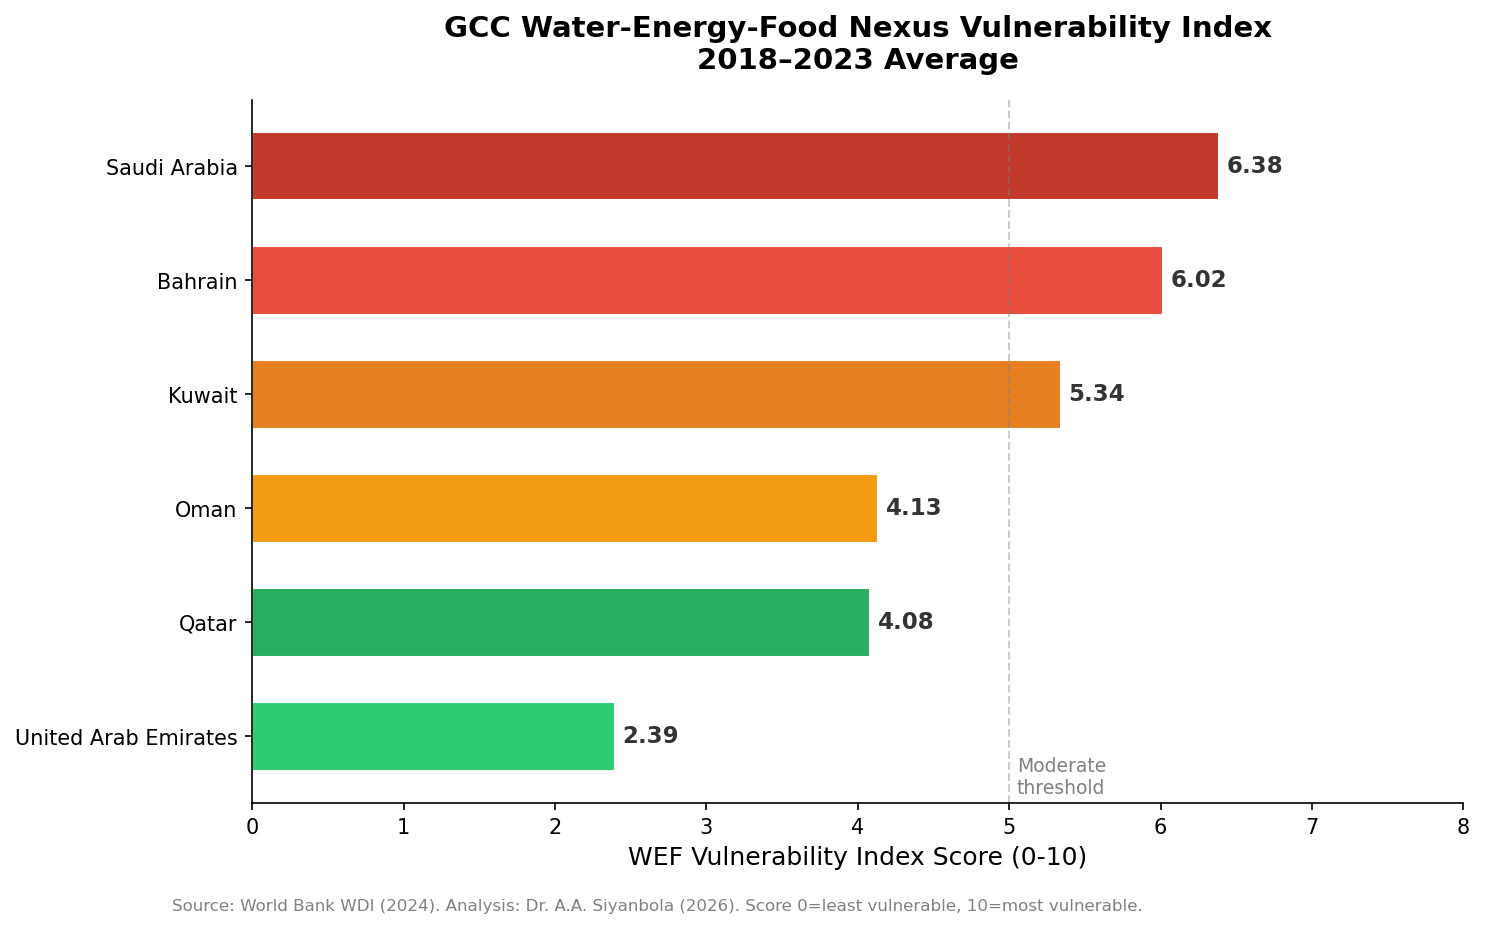

✓ Chart 1 saved!


In [3]:
# Sort by wef_index for the chart
chart1_data = final.sort_values('wef_index', ascending=True)

# Colour: darker = more vulnerable
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    chart1_data['country'],
    chart1_data['wef_index'],
    color=colors,
    edgecolor='white',
    height=0.6
)

# Add value labels on each bar
for bar, val in zip(bars, chart1_data['wef_index']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

# Labels and formatting
ax.set_xlabel('WEF Vulnerability Index Score (0-10)', fontsize=12)
ax.set_title(
    'GCC Water-Energy-Food Nexus Vulnerability Index\n2018–2023 Average',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlim(0, 8)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(5.05, -0.5, 'Moderate\nthreshold', fontsize=9, color='gray')

# Add footnote
fig.text(
    0.12, -0.02,
    'Source: World Bank WDI (2024). Analysis: Dr. A.A. Siyanbola (2026). '
    'Score 0=least vulnerable, 10=most vulnerable.',
    fontsize=8, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(charts_folder, 'chart1_wef_ranking.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("✓ Chart 1 saved!")

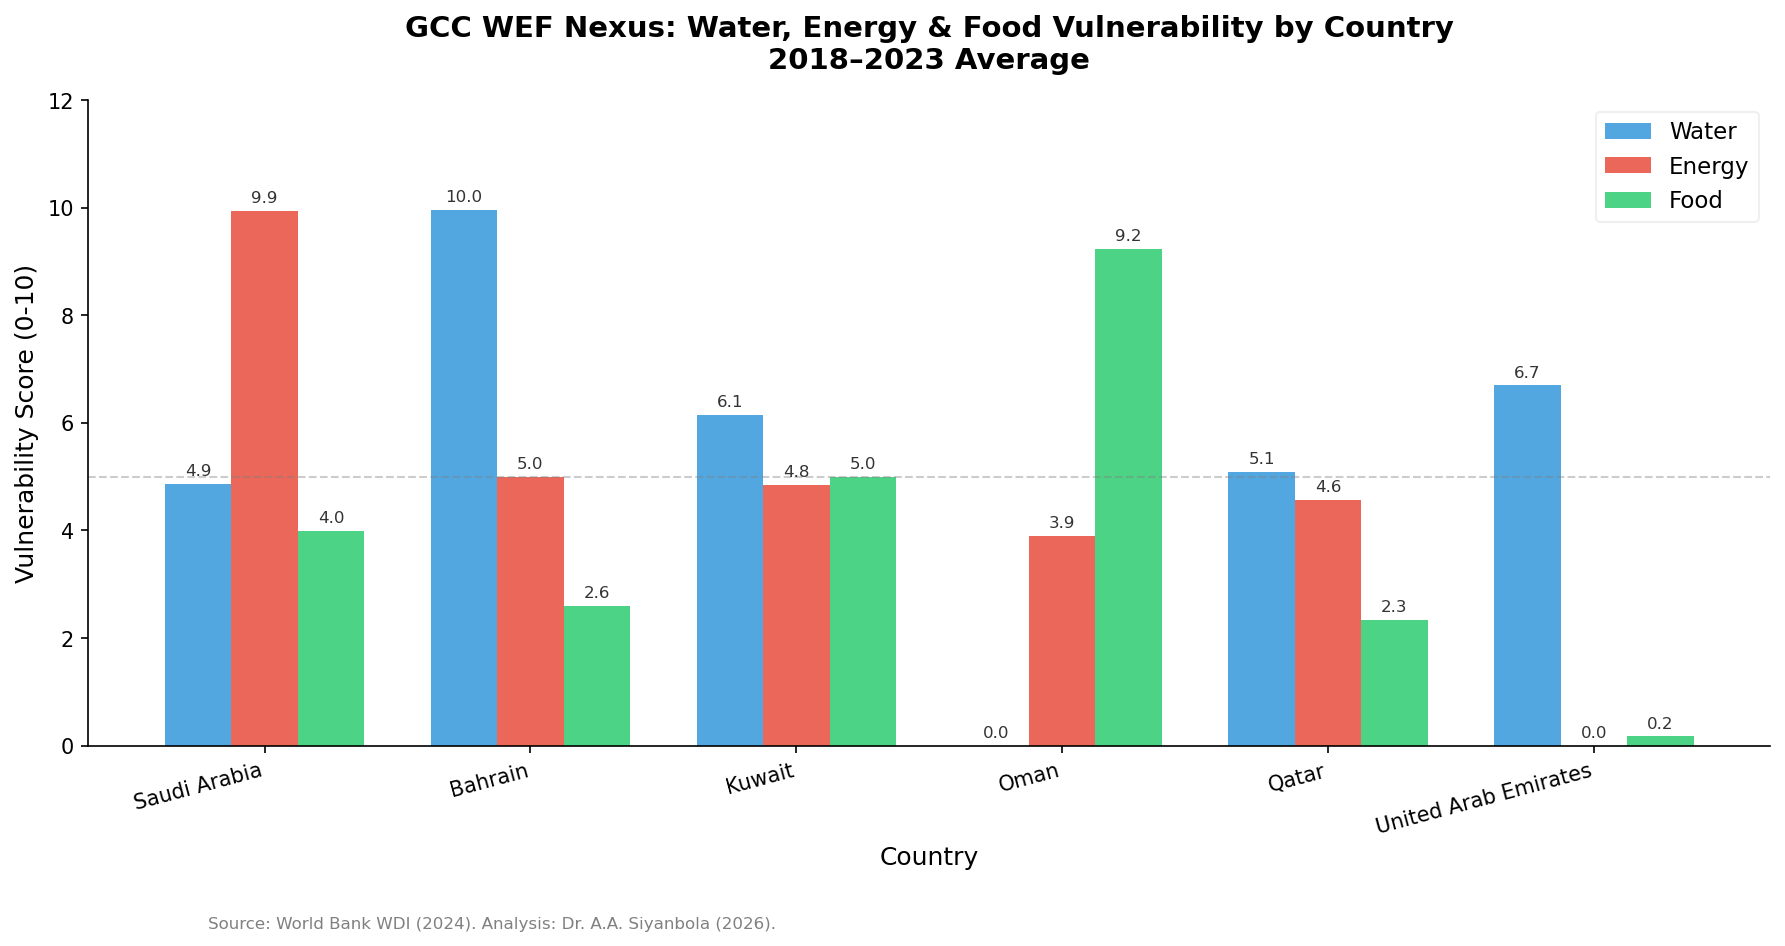

✓ Chart 2 saved!


In [4]:
# Sort by total wef_index
chart2_data = final.sort_values('wef_index', ascending=False)

countries = chart2_data['country']
x = np.arange(len(countries))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, chart2_data['water_score'], 
               width, label='Water', color='#3498db', alpha=0.85)
bars2 = ax.bar(x, chart2_data['energy_score'], 
               width, label='Energy', color='#e74c3c', alpha=0.85)
bars3 = ax.bar(x + width, chart2_data['food_score'], 
               width, label='Food', color='#2ecc71', alpha=0.85)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f'{height:.1f}',
            ha='center', va='bottom',
            fontsize=8, color='#333333'
        )

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Vulnerability Score (0-10)', fontsize=12)
ax.set_title(
    'GCC WEF Nexus: Water, Energy & Food Vulnerability by Country\n2018–2023 Average',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 12)
ax.legend(fontsize=11, framealpha=0.3)
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.4, linewidth=1)

fig.text(
    0.12, -0.04,
    'Source: World Bank WDI (2024). Analysis: Dr. A.A. Siyanbola (2026).',
    fontsize=8, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(charts_folder, 'chart2_component_scores.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()
print("✓ Chart 2 saved!")

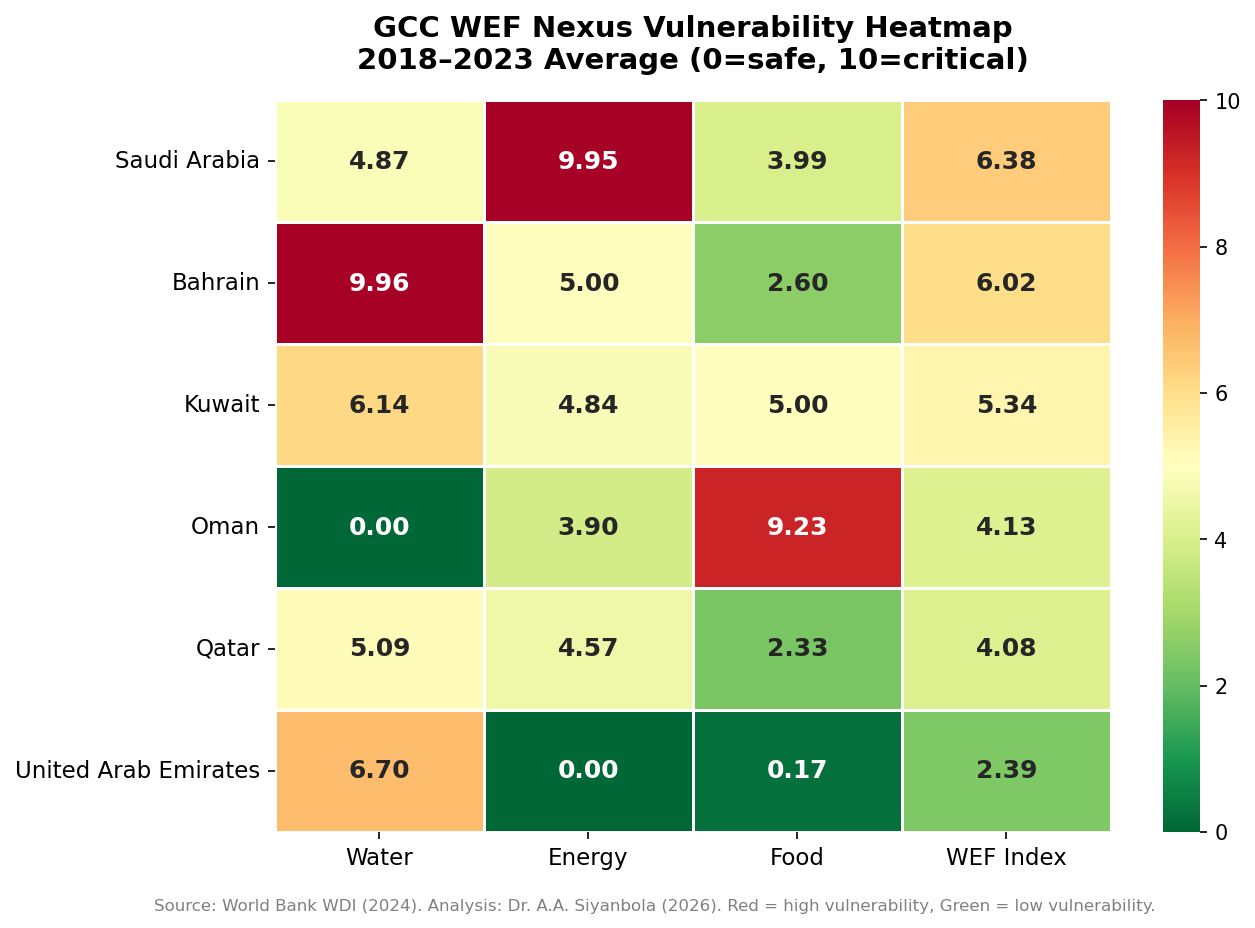

✓ Chart 3 saved!


In [5]:
# Build heatmap matrix
heatmap_data = final.set_index('country')[
    ['water_score', 'energy_score', 'food_score', 'wef_index']
].rename(columns={
    'water_score': 'Water',
    'energy_score': 'Energy',
    'food_score': 'Food',
    'wef_index': 'WEF Index'
}).sort_values('WEF Index', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=10,
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title(
    'GCC WEF Nexus Vulnerability Heatmap\n2018–2023 Average (0=safe, 10=critical)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11, rotation=0)

fig.text(
    0.12, -0.02,
    'Source: World Bank WDI (2024). Analysis: Dr. A.A. Siyanbola (2026). '
    'Red = high vulnerability, Green = low vulnerability.',
    fontsize=8, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(charts_folder, 'chart3_heatmap.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()
print("✓ Chart 3 saved!")

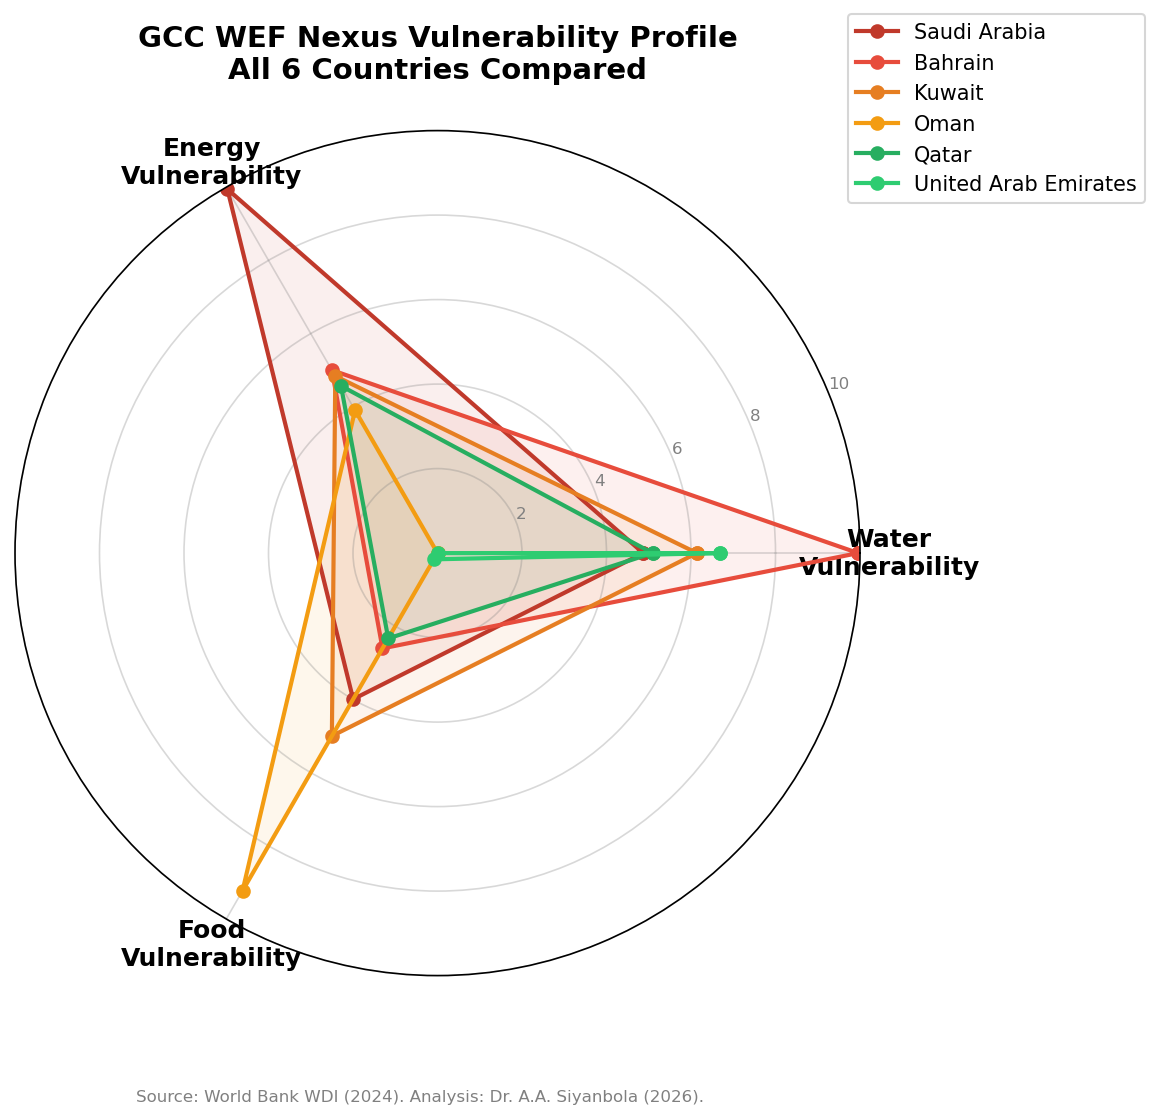

✓ Chart 4 saved!


In [6]:
# Radar chart - each country's vulnerability profile
categories = ['Water', 'Energy', 'Food']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#c0392b', '#e74c3c', '#e67e22', 
                '#f39c12', '#27ae60', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

chart4_data = final.sort_values('wef_index', ascending=False)

for i, (_, row) in enumerate(chart4_data.iterrows()):
    values = [row['water_score'], row['energy_score'], row['food_score']]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, 
            color=colors_radar[i], label=row['country'])
    ax.fill(angles, values, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Water\nVulnerability', 'Energy\nVulnerability', 
                     'Food\nVulnerability'], fontsize=12, fontweight='bold')
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8, color='gray')
ax.grid(color='gray', alpha=0.3)

ax.set_title(
    'GCC WEF Nexus Vulnerability Profile\nAll 6 Countries Compared',
    fontsize=14, fontweight='bold', pad=25
)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

fig.text(
    0.12, -0.01,
    'Source: World Bank WDI (2024). Analysis: Dr. A.A. Siyanbola (2026).',
    fontsize=8, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(charts_folder, 'chart4_radar.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()
print("✓ Chart 4 saved!")

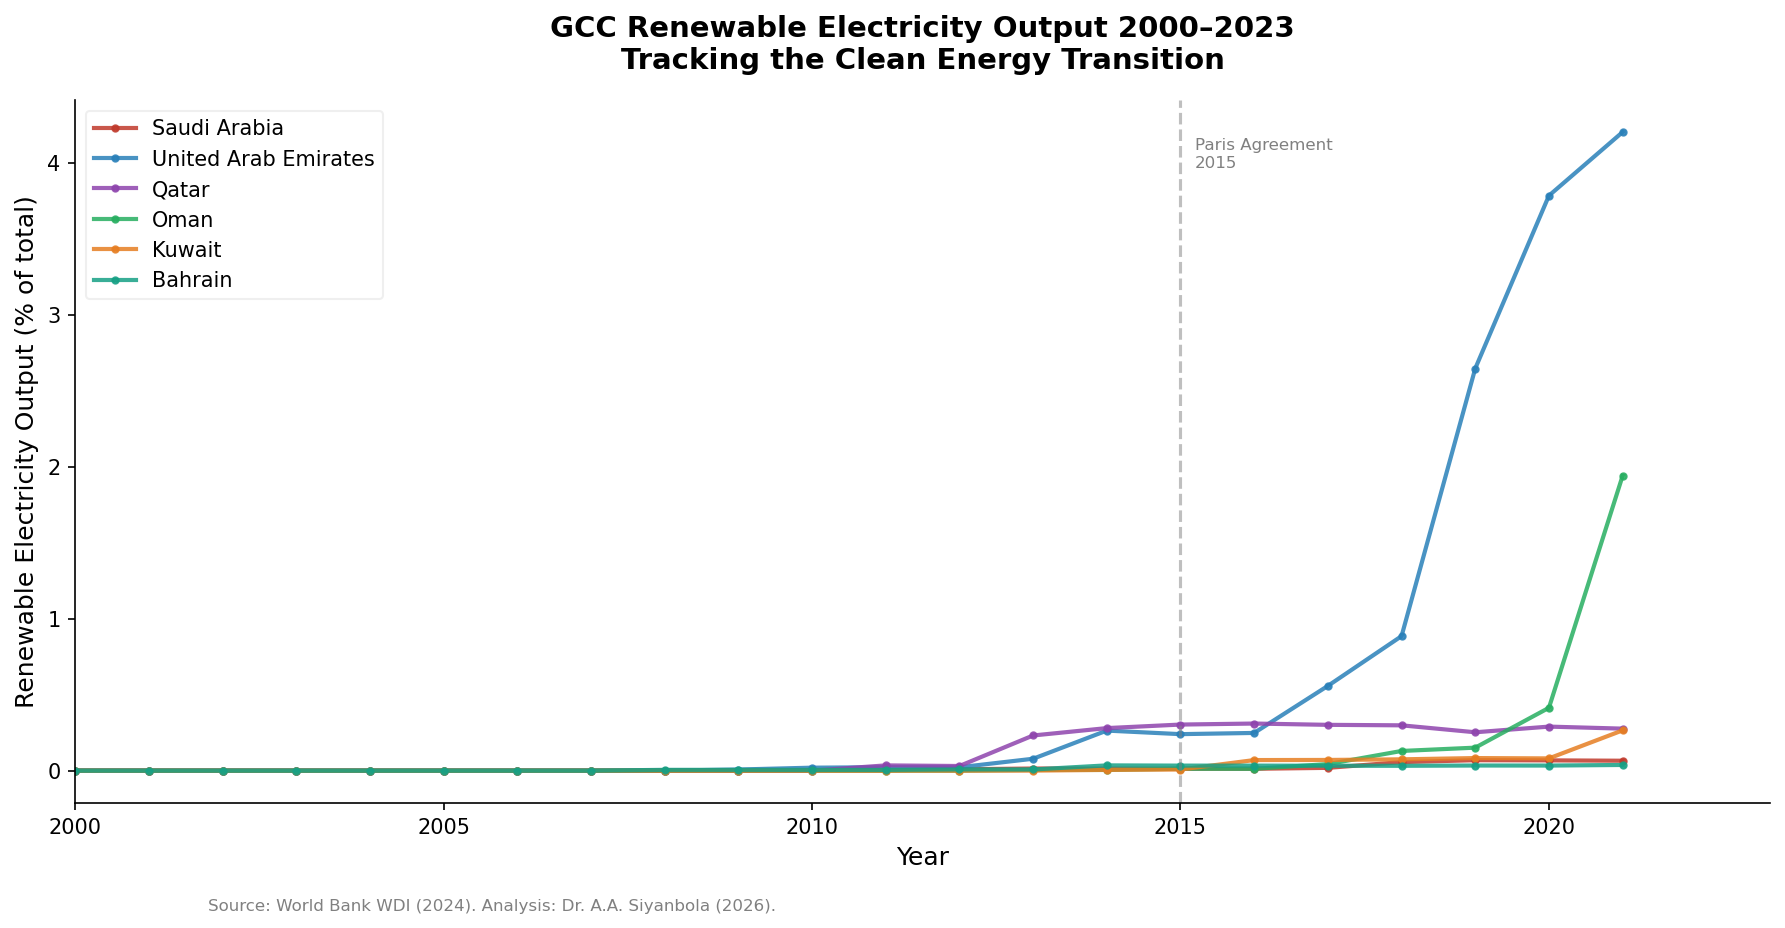

✓ Chart 5 saved!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_ts = {
    'Saudi Arabia': '#c0392b',
    'United Arab Emirates': '#2980b9',
    'Qatar': '#8e44ad',
    'Oman': '#27ae60',
    'Kuwait': '#e67e22',
    'Bahrain': '#16a085'
}

for country, color in colors_ts.items():
    country_data = master[master['country'] == country].sort_values('year')
    country_data = country_data.dropna(subset=['renewable_electricity'])
    
    ax.plot(
        country_data['year'],
        country_data['renewable_electricity'],
        marker='o', markersize=3,
        linewidth=2, color=color,
        label=country, alpha=0.85
    )

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Renewable Electricity Output (% of total)', fontsize=12)
ax.set_title(
    'GCC Renewable Electricity Output 2000–2023\nTracking the Clean Energy Transition',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(2000, 2023)
ax.legend(fontsize=10, framealpha=0.3, loc='upper left')
ax.axvline(x=2015, color='gray', linestyle='--', alpha=0.5)
ax.text(2015.2, ax.get_ylim()[1] * 0.9, 
        'Paris Agreement\n2015', fontsize=8, color='gray')

fig.text(
    0.12, -0.02,
    'Source: World Bank WDI (2024). Analysis: Dr. A.A. Siyanbola (2026).',
    fontsize=8, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(charts_folder, 'chart5_renewable_timeseries.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()
print("✓ Chart 5 saved!")

In [8]:
print("=" * 50)
print("ALL CHARTS SAVED IN YOUR CHARTS FOLDER")
print("=" * 50)
for f in os.listdir(charts_folder):
    print(f"  ✓ {f}")
print("\nLocation:", charts_folder)
print("\nPhase 4 complete!")

ALL CHARTS SAVED IN YOUR CHARTS FOLDER
  ✓ chart1_wef_ranking.png
  ✓ chart2_component_scores.png
  ✓ chart3_heatmap.png
  ✓ chart4_radar.png
  ✓ chart5_renewable_timeseries.png

Location: C:\Users\HP/Desktop/gcc-wef-nexus/charts

Phase 4 complete!
